# 7. The Ekert 91 protocol: entanglement-based security

The Ekert 91 protocol, named after Artur Ekert who proposed it in 1991 [1], is quite similar to the BB84 protocol. However, it directly utilizes the Bell experiment and, therefore, entanglement, for verification that the transmitted key is secure. In the following notebook, you will learn the details of the protocol and implement it yourself using what you have learned in the previous notebooks.

## 7.1. The Principle of E91
Unlike BB84, where security relies on the Heisenberg Uncertainty Principle and the disturbance caused by eavesdropping on single photons, the Ekert 91 (E91) protocol relies on **Quantum Entanglement** and the violation of **Bell's Inequalities**.

The core premise is this: If the statistics of the measurement results violate the CHSH inequality (a specific form of Bell's inequality), the system is guaranteed to be entangled. In a monogamous quantum system, if Alice and Bob share a maximally entangled state, that state cannot be correlated with any third party (Eve). Thus, a violation of the CHSH inequality mathematically certifies that no eavesdropper has information about the key.

**The Protocol Steps:**
1.  **Distribution:** A source generates pairs of entangled qubits (e.g., $|\Phi^+\rangle$) and sends one to Alice and one to Bob.
2.  **Measurement:** Alice and Bob independently and randomly choose a measurement basis from a pre-agreed set.
3.  **Sifting:** They announce their basis choices over a classical public channel.
4.  **Key Generation:** For the instances where their bases matched, their results are perfectly correlated (or anti-correlated). These bits form the **Raw Key**.
5.  **Security Check (Bell Test):** For the instances where their bases *did not* match, they use the correlation statistics to calculate the CHSH value $S$.
    * If $|S| \approx 2\sqrt{2}$, the channel is secure.
    * If $|S| \leq 2$, the system behaves classically (indicating decoherence or an eavesdropper measuring the line), and the protocol is aborted.

## 7.2. Defining the Measurement Bases
To simultaneously generate a key and perform a Bell test, we require specific measurement angles. We will use a standard set of 3 bases for each party.

*(Insert your illustration of the protocol and measurement bases here)*

**The Configuration:**
We define the measurement angles relative to the standard $Z$-basis ($0^\circ$).

* **Alice's Bases:**
    * $A_1 = 0^\circ$ (Standard $Z$)
    * $A_2 = 45^\circ$ (Hadamard basis $X$)
    * $A_3 = 90^\circ$
* **Bob's Bases:**
    * $B_1 = 45^\circ$
    * $B_2 = 90^\circ$
    * $B_3 = 135^\circ$

**Logic for Security vs. Key:**
* **Key Generation:** When Alice chooses $A_2$ and Bob chooses $B_1$ (both $45^\circ$), or when Alice chooses $A_3$ and Bob chooses $B_2$ (both $90^\circ$), their bases match. These results are used for the key.
* **Bell Test:** The remaining combinations (mismatched bases) are used to calculate the CHSH parameter $S$.

## 7.3. Implementation Task

You must now implement the quantum circuits required to simulate this protocol. You need to define two main components:
1.  **The Source:** A circuit that prepares the Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.
2.  **The Measurement Logic:** A function that applies the correct rotation gates to the qubit before measuring in the $Z$-basis.

*Recall that measuring a qubit in a basis rotated by $\theta$ is equivalent to applying a rotation gate $R_y(-\theta)$ followed by a standard $Z$-measurement.*

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
<strong>Your Task:</strong>
<br><br>
1. Write a function <code>create_bell_pair()</code> that returns a quantum circuit preparing the $|\Phi^+\rangle$ state.
<br>
2. Write a function <code>measure_in_basis(circuit, qubit, angle)</code>. This function should apply the necessary rotation gates to the specified qubit corresponding to the angle $\theta$, and then perform a measurement.
<br><br>
<em>Hint: For the basis angles $0, \pi/4, \pi/2$, etc., determine which standard gates ($H$, $S$, $X$, etc.) or general rotation gates ($R_y$) achieve the transformation.</em>
</div>

<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
  <summary style="cursor: pointer; color: #ffffff;">Solution (click to expand)</summary>
  <div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #ffffff;">
    <p><strong>1. The Bell Pair</strong><br>
    To create $|\Phi^+\rangle$, we start with $|00\rangle$, apply a Hadamard gate to the first qubit, and then a CNOT gate with the first qubit as control and the second as target.</p>
    <pre>
# Pseudocode logic
def create_bell_pair():
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    return qc
    </pre>

<p><strong>2. The Measurements</strong><br>
    Measurements in arbitrary bases are usually performed by rotating the basis back to the Z-axis. If we want to measure in a basis rotated by $\theta$ relative to Z, we apply a rotation of $-\theta$.</p>
    <ul>
        <li><strong>0° (Z-basis):</strong> No gate required. Measure directly.</li>
        <li><strong>90° (X-basis):</strong> Apply Hadamard ($H$).</li>
        <li><strong>45° / 135°:</strong> Use a generic $R_y(\theta)$ gate where $\theta$ corresponds to the basis angle. For example, to measure along an axis at $\pi/4$, apply $R_y(-\pi/4)$.</li>
    </ul>
  </div>
</details>

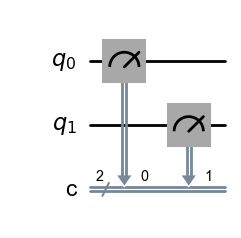

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

# 1. Define the source
def create_bell_pair():
    """
    Returns a QuantumCircuit with 2 qubits and 2 classical bits
    initialized in the Bell State |Phi+>
    """
    qc = QuantumCircuit(2, 2)

    # --- YOUR CODE HERE ---

    # ----------------------

    return qc

# 2. Define the measurement logic
def measure_in_basis(qc, qubit_index, angle):
    """
    Applies the necessary rotation to 'qubit_index' to measure in 'angle' basis.
    Then performs the measurement.
    """
    # --- YOUR CODE HERE ---
    # Hint: Use qc.ry(-angle, qubit_index) for arbitrary angles
    # or specific gates like H for 90 degrees.
    pass

    # ----------------------
    qc.measure(qubit_index, qubit_index)

# Test your functions
qc_test = create_bell_pair()
measure_in_basis(qc_test, 0, 0)       # Measure qubit 0 in Z basis
measure_in_basis(qc_test, 1, np.pi/2) # Measure qubit 1 in X basis
qc_test.draw(output='mpl')

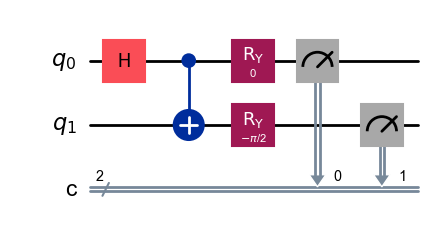

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

# 1. Define the source
def create_bell_pair():
    """
    Returns a QuantumCircuit with 2 qubits and 2 classical bits
    initialized in the Bell State |Phi+>
    """
    qc = QuantumCircuit(2, 2)

    # Apply H to the first qubit
    qc.h(0)
    # Apply CNOT with 0 as control and 1 as target
    qc.cx(0, 1)

    return qc

# 2. Define the measurement logic
def measure_in_basis(qc, qubit_index, angle):
    """
    Applies the necessary rotation to 'qubit_index' to measure in 'angle' basis.
    Then performs the measurement.
    """
    # Rotate the state by -angle around the Y-axis to align
    # the measurement basis with the Z-axis.
    qc.ry(-angle, qubit_index)

    # Perform the standard Z-measurement
    qc.measure(qubit_index, qubit_index)

# Test your functions
qc_test = create_bell_pair()
measure_in_basis(qc_test, 0, 0)       # Measure qubit 0 in Z basis
measure_in_basis(qc_test, 1, np.pi/2) # Measure qubit 1 in X basis
qc_test.draw(output='mpl')

## 7.4. Verification: The CHSH Correlation Test

Once you have run the simulation for many "shots" (iterations), you will have a dataset of measurement results for different basis combinations. To verify entanglement, we calculate the CHSH correlation value $S$.

The value $S$ is defined as:
$$S = E(A_1, B_1) - E(A_1, B_3) + E(A_3, B_1) + E(A_3, B_3)$$

Where $E(A_x, B_y)$ is the **correlation coefficient** for the measurement results when Alice chose basis $A_x$ and Bob chose basis $B_y$.

The correlation $E$ is calculated as:
$$E = \frac{N_{same} - N_{diff}}{N_{total}}$$
Where $N_{same}$ is the number of times Alice and Bob got the same result (00 or 11), and $N_{diff}$ is the number of times they got different results (01 or 10).

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
<strong>Your Task:</strong>
<br><br>
1. Simulate the protocol for 1000 shots using random basis choices for Alice and Bob.
<br>
2. Filter the results to calculate the correlation coefficient $E$ for the four specific pairs required for the CHSH inequality: $(A_1, B_1)$, $(A_1, B_3)$, $(A_3, B_1)$, and $(A_3, B_3)$.
<br>
3. Compute $S$. Does your result violate the classical bound of 2?
</div>
<p>

<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
  <summary style="cursor: pointer; color: #ffffff;">Solution (click to expand)</summary>
  <div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #ffffff;">
    <p><strong>Expected Result:</strong></p>
    <p>For a maximally entangled state $|\Phi^+\rangle$ and the angles specified above:</p>
    <ul>
        <li>$E(A_1, B_1)$ should be approx $\frac{1}{\sqrt{2}} \approx 0.707$</li>
        <li>$E(A_1, B_3)$ should be approx $-\frac{1}{\sqrt{2}} \approx -0.707$</li>
        <li>$E(A_3, B_1)$ should be approx $\frac{1}{\sqrt{2}} \approx 0.707$</li>
        <li>$E(A_3, B_3)$ should be approx $\frac{1}{\sqrt{2}} \approx 0.707$</li>
    </ul>
    <p>Calculating $S$:</p>
    $$S = 0.707 - (-0.707) + 0.707 + 0.707 \approx 2.828$$
    <p>This value is close to $2\sqrt{2}$, which violates the classical limit of 2, proving the presence of entanglement and the security of the protocol.</p>
  </div>
</details>

In [4]:
# Simulation Parameters
shots = 1000
backend = AerSimulator()

# Basis angles (in radians)
# A1=0 (Z), A2=pi/4, A3=pi/2 (X)
alice_bases = [0, np.pi/4, np.pi/2]
# B1=pi/4, B2=pi/2, B3=3pi/4
bob_bases = [np.pi/4, np.pi/2, 3*np.pi/4]

# Dictionary to store counts: keys are tuples (alice_idx, bob_idx)
# Values will be dictionaries {'same': 0, 'diff': 0}
correlation_counts = {}

print(f"Running {shots} shots...")

# --- SIMULATION LOOP ---
for i in range(shots):
    # 1. Randomly select an index for Alice (0, 1, 2) and Bob (0, 1, 2)
    a_idx = np.random.randint(0, 3)
    b_idx = np.random.randint(0, 3)

    # 2. Create the Bell pair circuit
    qc = create_bell_pair()

    # 3. Apply measure_in_basis
    # Note: We pass the actual angles from our lists using the random indices
    measure_in_basis(qc, 0, alice_bases[a_idx])
    measure_in_basis(qc, 1, bob_bases[b_idx])

    # 4. Execute the circuit
    # We use shots=1 and memory=True to get the individual measurement string
    result = backend.run(qc, shots=1, memory=True).result()
    result_string = result.get_memory()[0] # e.g., '00', '01', '10', '11'

    # 5. Store the results
    pair_key = (a_idx, b_idx)

    # Initialize dictionary for this pair if not exists
    if pair_key not in correlation_counts:
        correlation_counts[pair_key] = {'same': 0, 'diff': 0}

    # Check correlation: '00' or '11' are SAME; '01' or '10' are DIFF
    # Note: result_string is 'qubit1 qubit0', but equality check is symmetric
    if result_string[0] == result_string[1]:
        correlation_counts[pair_key]['same'] += 1
    else:
        correlation_counts[pair_key]['diff'] += 1


# --- CALCULATE S ---

def calculate_E(a_idx, b_idx):
    """Helper to calculate Correlation Coefficient E for a given pair of bases"""
    data = correlation_counts.get((a_idx, b_idx), {'same': 0, 'diff': 0})
    same = data['same']
    diff = data['diff']
    total = same + diff

    if total == 0: return 0 # Avoid division by zero if random sampling missed a pair
    return (same - diff) / total

# Indices mapping: A1->0, A3->2, B1->0, B3->2
# Formula: S = E(A1, B1) - E(A1, B3) + E(A3, B1) + E(A3, B3)

E_a1_b1 = calculate_E(0, 0)
E_a1_b3 = calculate_E(0, 2)
E_a3_b1 = calculate_E(2, 0)
E_a3_b3 = calculate_E(2, 2)

S = E_a1_b1 - E_a1_b3 + E_a3_b1 + E_a3_b3

print("-" * 30)
print(f"E(A1, B1): {E_a1_b1:.3f}")
print(f"E(A1, B3): {E_a1_b3:.3f}")
print(f"E(A3, B1): {E_a3_b1:.3f}")
print(f"E(A3, B3): {E_a3_b3:.3f}")
print("-" * 30)
print(f"Calculated S value: {S:.4f}")
print(f"Violation of Classical Bound (2.0): {abs(S) > 2.0}")

Running 1000 shots...
------------------------------
E(A1, B1): 0.726
E(A1, B3): -0.738
E(A3, B1): 0.817
E(A3, B3): 0.667
------------------------------
Calculated S value: 2.9468
Violation of Classical Bound (2.0): True


### 7.5. Outlook: The Zoo of QKD Protocols

While this course focused on **E91** (Entanglement-based) and mentioned **BB84** (Prepare-and-Measure), the field of Quantum Key Distribution is vast. Researchers have developed numerous other protocols to address different challenges, such as hardware simplicity, noise tolerance, or transmission distance.

Here are a few notable protocols you might encounter in advanced studies:

#### 1. B92 Protocol (Bennett, 1992) [2]

If BB84 is the "standard" and E91 is the "paranoid" version, **B92** is the "minimalist."
* **Concept:** Instead of using 4 states across 2 bases (like BB84), B92 uses only **two non-orthogonal states** (e.g., $|0\rangle$ and $|+\rangle$).
* **How it works:** Bob measures in a basis complementary to the bit he *guesses* Alice sent. If he detects a photon, he knows for sure what Alice sent (erasure channel logic).
* **Advantage:** It requires simpler hardware state preparation.

#### 2. Six-State Protocol (1998) [3]
This is the "maximalist" extension of BB84.
* **Concept:** Instead of using just the Z-basis ($|0\rangle, |1\rangle$) and X-basis ($|+\rangle, |-\rangle$), Alice and Bob use **all three** mutually unbiased bases (X, Y, and Z).
* **Advantage:** By checking for errors in all three directions on the Bloch sphere, this protocol puts tighter constraints on an eavesdropper. It can tolerate a higher Bit Error Rate (up to \~12.6%) than BB84 (\~11%) before security is lost.

#### 3. Continuous Variable QKD (CV-QKD) [4]
Most protocols we discussed are **Discrete Variable (DV-QKD)**, counting individual photons.
* **Concept:** CV-QKD encodes information in the continuous properties of light waves, such as **amplitude and phase** (position and momentum quadratures), rather than polarization.
* **Advantage:** It does not require specialized single-photon detectors. It can use standard telecommunication components (homodyne detectors), making it potentially cheaper and easier to integrate into existing fiber optic networks.

#### 4. Twin-Field QKD (TF-QKD) [5]
One of the biggest problems in QKD is distance—photons get lost in fiber optics.
* **Concept:** Instead of sending a photon all the way from Alice to Bob, both Alice and Bob send weak pulses to a central station (Charlie) which performs a measurement.
* **Advantage:** This clever interference trick allows the key rate to scale with the square root of the channel loss, significantly extending the maximum distance for secure communication (hundreds of kilometers).

## 7.6. Conclusion

In this notebook, we transformed the abstract physics of the Bell inequality into a concrete cryptographic protocol: **E91**.

We demonstrated that quantum security does not rely on the computational difficulty of math problems (like RSA), but on the fundamental laws of physics. By interweaving **Key Generation** rounds with **Bell Test** rounds, we created a system that is self-auditing.


### Key Takeaways
1.  **Monogamy of Entanglement:** This is the critical security feature. If Alice and Bob verify that they share a maximally entangled state (by observing $|S| \approx 2.82$), it is physically impossible for an eavesdropper (Eve) to be correlated with their system. Entanglement cannot be shared with a third party.
2.  **Statistical Certification:** We do not need to trust the source of the photons. Even if the device was built by Eve, the violation of the CHSH inequality proves she has lost control of the correlations.
3.  **The Outcome:** A shared, random sequence of bits (the raw key) that can be used for a **One-Time Pad**, the only mathematically unbreakable encryption method known.

### What's Next?
We have used entanglement to prove non-locality (Bell) and to generate secrets (E91). In the next notebook, we will use it for its most famous application: **Quantum Teleportation**, where we will use an entangled pair to transport a quantum state across space.

## References

[1] Ekert, A. (1991) Quantum Cryptography Based on Bell’s Theorem. Physical Review Letters, 67, 661-663. https://doi.org/10.1103/PhysRevLett.67.661

[2] Bennett, C. H. (1992). Quantum cryptography using any two nonorthogonal states. Physical review letters, 68(21), 3121.

[3] Bruß, D. (1998). Optimal eavesdropping in quantum cryptography with six states. Physical Review Letters, 81(14), 3018.

[4] Grosshans, F., & Grangier, P. (2002). Continuous variable quantum cryptography using coherent states. Physical review letters, 88(5), 057902.

[5] Lucamarini, M., Yuan, Z. L., Dynes, J. F., & Shields, A. J. (2018). Overcoming the rate–distance limit of quantum key distribution without quantum repeaters. Nature, 557(7705), 400-403.